# Phase 5 — Inventory Simulation / Digital Twin

In this phase, we simulate how inventory changes over time using forecasted demand and replenishment decisions.

The goal is to create a simplified digital representation of warehouse inventory behavior.

## 5.1 Prepare Simulation Inputs

We use:
- Current inventory levels
- Daily demand forecasts
- Replenishment recommendations

These inputs will allow us to simulate stock evolution over the 14-day forecast horizon.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

inventory = pd.read_csv("../data/inventory.csv")

future_forecasts = pd.read_csv(
    "../data/future_forecasts_14d.csv"
)

replenishment_decisions = pd.read_csv(
    "../data/replenishment_decisions.csv"
)

inventory.head()

,product_id,current_stock,reorder_point,max_stock
0,P001,12,5,30
1,P002,8,10,40
2,P003,15,8,35
3,P004,4,5,20
4,P005,20,6,30


In [ ]:
print("Inventory shape:", inventory.shape)
print("Forecast shape:", future_forecasts.shape)
print("Decisions shape:", replenishment_decisions.shape)

print("\nForecast date range:")
print(
    future_forecasts["date"].min(),
    "->",
    future_forecasts["date"].max()
)

print("\nProducts in forecast:")
print(future_forecasts["product_id"].nunique())

Inventory shape: (10, 4)
Forecast shape: (140, 4)
Decisions shape: (10, 10)

Forecast date range:
2026-01-01 -> 2026-01-14

Products in forecast:
10


## 5.2 Simulate Inventory Evolution for Product P001

Before simulating the entire warehouse, we start with one product to understand the inventory logic clearly.

For each future day:
- Start from the current stock
- Apply the recommended replenishment quantity
- Subtract forecasted daily demand
- Track the remaining stock
- Detect whether a stockout occurs

This creates a simple digital representation of inventory behavior over time.

In [ ]:
product_id = "P001"

p001_forecast = (
    future_forecasts[
        future_forecasts["product_id"] == product_id
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

p001_inventory = inventory[
    inventory["product_id"] == product_id
].iloc[0]

p001_decision = replenishment_decisions[
    replenishment_decisions["product_id"] == product_id
].iloc[0]

p001_forecast.head()

,date,product_id,forecast_demand,forecast_units
0,2026-01-01,P001,6.922278,7
1,2026-01-02,P001,6.880886,7
2,2026-01-03,P001,6.056123,6
3,2026-01-04,P001,5.219498,5
4,2026-01-05,P001,6.607964,7


In [ ]:
print("Product:", product_id)
print("Starting stock:", p001_inventory["current_stock"])
print(
    "Recommended reorder quantity:",
    p001_decision["forecast_based_reorder_qty"]
)

print("\nDaily forecast:")
print(
    p001_forecast[
        ["date", "forecast_units"]
    ]
)

Product: P001
Starting stock: 12
Recommended reorder quantity: 18

Daily forecast:
          date  forecast_units
0   2026-01-01               7
1   2026-01-02               7
2   2026-01-03               6
3   2026-01-04               5
4   2026-01-05               7
5   2026-01-06               7
6   2026-01-07               8
7   2026-01-08               7
8   2026-01-09               7
9   2026-01-10               6
10  2026-01-11               5
11  2026-01-12               6
12  2026-01-13               6
13  2026-01-14               7


## 5.3 Simulate Daily Inventory Changes for P001

We now simulate the daily inventory evolution of product `P001`.

The simulation starts from the current stock, applies the recommended replenishment quantity at the beginning, and then subtracts forecasted demand each day.

For each day, we track:
- Starting stock
- Replenishment received
- Forecasted demand
- Ending stock
- Stockout quantity, if demand exceeds available inventory

This helps evaluate whether the replenishment recommendation is sufficient over the forecast horizon.

In [ ]:
starting_stock = int(p001_inventory["current_stock"])
reorder_qty = int(
    p001_decision["forecast_based_reorder_qty"]
)

current_stock = starting_stock + reorder_qty

simulation_rows = []

for _, row in p001_forecast.iterrows():

    demand = int(row["forecast_units"])

    stock_before_demand = current_stock

    fulfilled_demand = min(
        stock_before_demand,
        demand
    )

    stockout_qty = max(
        0,
        demand - stock_before_demand
    )

    ending_stock = max(
        0,
        stock_before_demand - demand
    )

    simulation_rows.append({
        "date": row["date"],
        "starting_stock": stock_before_demand,
        "forecast_demand": demand,
        "fulfilled_demand": fulfilled_demand,
        "stockout_qty": stockout_qty,
        "ending_stock": ending_stock
    })

    current_stock = ending_stock


p001_simulation = pd.DataFrame(simulation_rows)

p001_simulation

,date,starting_stock,forecast_demand,fulfilled_demand,stockout_qty,ending_stock
0,2026-01-01,30,7,7,0,23
1,2026-01-02,23,7,7,0,16
2,2026-01-03,16,6,6,0,10
3,2026-01-04,10,5,5,0,5
4,2026-01-05,5,7,5,2,0
5,2026-01-06,0,7,0,7,0
6,2026-01-07,0,8,0,8,0
7,2026-01-08,0,7,0,7,0
8,2026-01-09,0,7,0,7,0
9,2026-01-10,0,6,0,6,0


## 5.4 Calculate Simulation KPIs

To evaluate the inventory simulation, we calculate summary performance indicators.

We measure:
- Total forecast demand
- Total fulfilled demand
- Total stockout quantity
- Service level
- First stockout date

These KPIs help evaluate whether the replenishment policy is sufficient over the forecast horizon.

In [ ]:
total_demand = p001_simulation["forecast_demand"].sum()

total_fulfilled = p001_simulation["fulfilled_demand"].sum()

total_stockout = p001_simulation["stockout_qty"].sum()

service_level = (
    total_fulfilled / total_demand
    if total_demand > 0
    else np.nan
)

stockout_days = p001_simulation[
    p001_simulation["stockout_qty"] > 0
]

first_stockout_date = (
    stockout_days["date"].iloc[0]
    if not stockout_days.empty
    else None
)

print("Total forecast demand:", total_demand)
print("Total fulfilled demand:", total_fulfilled)
print("Total stockout quantity:", total_stockout)
print("Service level:", round(service_level * 100, 2), "%")
print("First stockout date:", first_stockout_date)

Total forecast demand: 91
Total fulfilled demand: 30
Total stockout quantity: 61
Service level: 32.97 %
First stockout date: 2026-01-05


## 5.5 Compare the Current Policy with an Improved Replenishment Scenario

The current replenishment policy limits inventory to the configured `max_stock`.

The simulation showed that this policy was not sufficient for product `P001`, because stockout occurred early in the forecast horizon.

We now test an improved scenario where the replenishment quantity is large enough to cover the full 14-day forecast demand.

This what-if experiment allows us to compare:
- Current replenishment policy
- Improved forecast-covering policy

In [ ]:
improved_reorder_qty = max(
    0,
    total_demand - starting_stock
)

print("Current reorder quantity:", reorder_qty)
print("Improved reorder quantity:", improved_reorder_qty)

Current reorder quantity: 18
Improved reorder quantity: 79


In [ ]:
current_stock = starting_stock + improved_reorder_qty

improved_simulation_rows = []

for _, row in p001_forecast.iterrows():

    demand = int(row["forecast_units"])

    stock_before_demand = current_stock

    fulfilled_demand = min(
        stock_before_demand,
        demand
    )

    stockout_qty = max(
        0,
        demand - stock_before_demand
    )

    ending_stock = max(
        0,
        stock_before_demand - demand
    )

    improved_simulation_rows.append({
        "date": row["date"],
        "starting_stock": stock_before_demand,
        "forecast_demand": demand,
        "fulfilled_demand": fulfilled_demand,
        "stockout_qty": stockout_qty,
        "ending_stock": ending_stock
    })

    current_stock = ending_stock


p001_improved_simulation = pd.DataFrame(
    improved_simulation_rows
)

p001_improved_simulation

,date,starting_stock,forecast_demand,fulfilled_demand,stockout_qty,ending_stock
0,2026-01-01,91,7,7,0,84
1,2026-01-02,84,7,7,0,77
2,2026-01-03,77,6,6,0,71
3,2026-01-04,71,5,5,0,66
4,2026-01-05,66,7,7,0,59
5,2026-01-06,59,7,7,0,52
6,2026-01-07,52,8,8,0,44
7,2026-01-08,44,7,7,0,37
8,2026-01-09,37,7,7,0,30
9,2026-01-10,30,6,6,0,24


In [ ]:
improved_total_fulfilled = (
    p001_improved_simulation["fulfilled_demand"].sum()
)

improved_total_stockout = (
    p001_improved_simulation["stockout_qty"].sum()
)

improved_service_level = (
    improved_total_fulfilled / total_demand
    if total_demand > 0
    else np.nan
)

print("Improved fulfilled demand:", improved_total_fulfilled)
print("Improved stockout quantity:", improved_total_stockout)
print(
    "Improved service level:",
    round(improved_service_level * 100, 2),
    "%"
)

Improved fulfilled demand: 91
Improved stockout quantity: 0
Improved service level: 100.0 %


## 5.6 Compare Current and Improved Inventory Scenarios

To better understand the impact of the replenishment policy, we compare the inventory evolution of two scenarios:

- Current policy: replenishment is limited by `max_stock`
- Improved scenario: replenishment is sufficient to cover the full 14-day forecast

The comparison helps visualize how replenishment quantity affects stock availability and stockout risk.

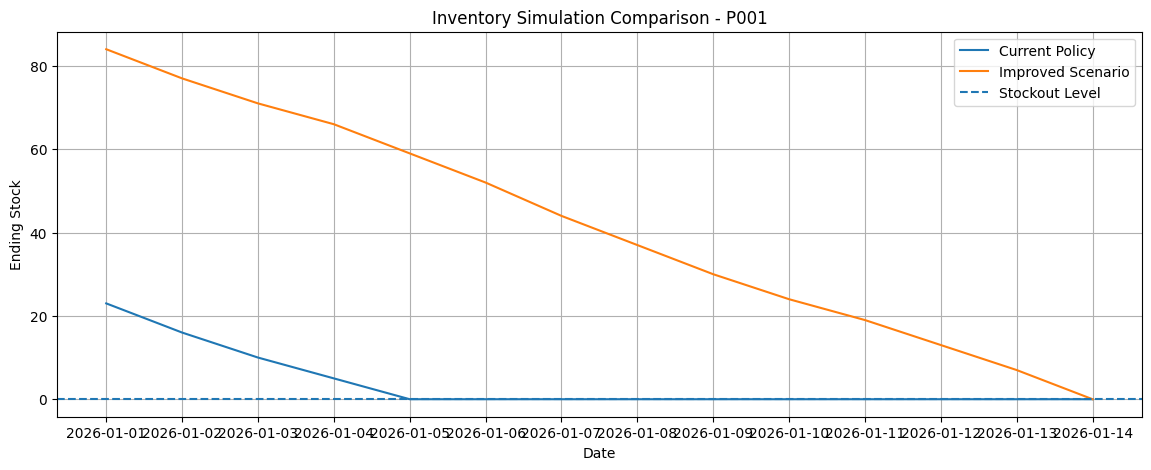

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    p001_simulation["date"],
    p001_simulation["ending_stock"],
    label="Current Policy"
)

plt.plot(
    p001_improved_simulation["date"],
    p001_improved_simulation["ending_stock"],
    label="Improved Scenario"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Stockout Level"
)

plt.title("Inventory Simulation Comparison - P001")
plt.xlabel("Date")
plt.ylabel("Ending Stock")
plt.legend()
plt.grid(True)

plt.show()

## 5.7 Simulate Inventory for All Products

After validating the simulation logic on product `P001`, we extend the same process to all products.

For each product, we:
- Start from current inventory
- Apply the recommended reorder quantity
- Subtract forecasted daily demand
- Track fulfilled demand and stockouts
- Calculate final simulation KPIs

This creates a warehouse-level inventory simulation.

In [ ]:
all_simulation_rows = []

for product_id in inventory["product_id"].unique():

    product_forecast = (
        future_forecasts[
            future_forecasts["product_id"] == product_id
        ]
        .copy()
        .sort_values("date")
        .reset_index(drop=True)
    )

    product_inventory = inventory[
        inventory["product_id"] == product_id
    ].iloc[0]

    product_decision = replenishment_decisions[
        replenishment_decisions["product_id"] == product_id
    ].iloc[0]

    starting_stock = int(product_inventory["current_stock"])

    reorder_qty = int(
        product_decision["forecast_based_reorder_qty"]
    )

    current_stock = starting_stock + reorder_qty

    for _, row in product_forecast.iterrows():

        demand = int(row["forecast_units"])

        stock_before_demand = current_stock

        fulfilled_demand = min(
            stock_before_demand,
            demand
        )

        stockout_qty = max(
            0,
            demand - stock_before_demand
        )

        ending_stock = max(
            0,
            stock_before_demand - demand
        )

        all_simulation_rows.append({
            "date": row["date"],
            "product_id": product_id,
            "starting_stock": stock_before_demand,
            "forecast_demand": demand,
            "fulfilled_demand": fulfilled_demand,
            "stockout_qty": stockout_qty,
            "ending_stock": ending_stock
        })

        current_stock = ending_stock

In [ ]:
all_simulation_df = pd.DataFrame(
    all_simulation_rows
)

print("Simulation shape:", all_simulation_df.shape)

all_simulation_df.head(20)

Simulation shape: (140, 7)


,date,product_id,starting_stock,forecast_demand,fulfilled_demand,stockout_qty,ending_stock
0,2026-01-01,P001,30,7,7,0,23
1,2026-01-02,P001,23,7,7,0,16
2,2026-01-03,P001,16,6,6,0,10
3,2026-01-04,P001,10,5,5,0,5
4,2026-01-05,P001,5,7,5,2,0
5,2026-01-06,P001,0,7,0,7,0
6,2026-01-07,P001,0,8,0,8,0
7,2026-01-08,P001,0,7,0,7,0
8,2026-01-09,P001,0,7,0,7,0
9,2026-01-10,P001,0,6,0,6,0


## 5.8 Calculate Warehouse-Level Simulation KPIs

After simulating all products, we summarize the results at the warehouse level.

We calculate:
- Total forecast demand
- Total fulfilled demand
- Total stockout quantity
- Overall service level
- Number of products that experienced at least one stockout

These KPIs provide a global view of how well the current replenishment policy performs across the warehouse.

In [ ]:
warehouse_total_demand = (
    all_simulation_df["forecast_demand"].sum()
)

warehouse_total_fulfilled = (
    all_simulation_df["fulfilled_demand"].sum()
)

warehouse_total_stockout = (
    all_simulation_df["stockout_qty"].sum()
)

warehouse_service_level = (
    warehouse_total_fulfilled / warehouse_total_demand
    if warehouse_total_demand > 0
    else np.nan
)

products_with_stockout = (
    all_simulation_df[
        all_simulation_df["stockout_qty"] > 0
    ]["product_id"]
    .nunique()
)

print("Warehouse total demand:", warehouse_total_demand)
print("Warehouse fulfilled demand:", warehouse_total_fulfilled)
print("Warehouse stockout quantity:", warehouse_total_stockout)
print(
    "Warehouse service level:",
    round(warehouse_service_level * 100, 2),
    "%"
)
print("Products with stockout:", products_with_stockout)

Warehouse total demand: 1286
Warehouse fulfilled demand: 277
Warehouse stockout quantity: 1009
Warehouse service level: 21.54 %
Products with stockout: 10


## 5.9 Build a Product-Level Simulation Summary

Warehouse-level KPIs show the overall performance of the replenishment policy, but they do not identify which products are performing worst.

We therefore calculate simulation KPIs for each product.

For every product, we measure:
- Total forecast demand
- Total fulfilled demand
- Total stockout quantity
- Product service level
- Number of stockout days

This helps identify the products that require the most urgent policy improvement.

In [ ]:
product_simulation_summary = (
    all_simulation_df
    .groupby("product_id")
    .agg(
        total_demand=("forecast_demand", "sum"),
        fulfilled_demand=("fulfilled_demand", "sum"),
        stockout_qty=("stockout_qty", "sum"),
        stockout_days=("stockout_qty", lambda x: (x > 0).sum())
    )
    .reset_index()
)

product_simulation_summary["service_level"] = (
    product_simulation_summary["fulfilled_demand"]
    / product_simulation_summary["total_demand"]
    * 100
)

product_simulation_summary["service_level"] = (
    product_simulation_summary["service_level"]
    .round(2)
)

product_simulation_summary = (
    product_simulation_summary
    .sort_values("service_level")
    .reset_index(drop=True)
)

product_simulation_summary

,product_id,total_demand,fulfilled_demand,stockout_qty,stockout_days,service_level
0,P002,265,40,225,13,15.09
1,P006,99,15,84,12,15.15
2,P010,163,30,133,12,18.40
3,P008,201,40,161,12,19.90
4,P003,158,35,123,12,22.15
5,P005,128,30,98,11,23.44
6,P009,82,25,57,10,30.49
7,P004,62,20,42,10,32.26
8,P007,37,12,25,10,32.43
9,P001,91,30,61,10,32.97


## 5.10 Simulate an Improved Warehouse Scenario

The current replenishment policy produced a low warehouse service level and stockouts across all products.

We therefore test a simplified improved scenario where each product receives enough inventory to cover its full 14-day forecast demand.

This scenario is not considered an optimized policy. It is a what-if experiment used to measure the effect of increasing replenishment quantities.

In [ ]:
improved_all_rows = []

for product_id in inventory["product_id"].unique():

    product_forecast = (
        future_forecasts[
            future_forecasts["product_id"] == product_id
        ]
        .copy()
        .sort_values("date")
        .reset_index(drop=True)
    )

    product_inventory = inventory[
        inventory["product_id"] == product_id
    ].iloc[0]

    starting_stock = int(
        product_inventory["current_stock"]
    )

    total_product_demand = int(
        product_forecast["forecast_units"].sum()
    )

    improved_reorder_qty = max(
        0,
        total_product_demand - starting_stock
    )

    current_stock = (
        starting_stock + improved_reorder_qty
    )

    for _, row in product_forecast.iterrows():

        demand = int(row["forecast_units"])

        stock_before_demand = current_stock

        fulfilled_demand = min(
            stock_before_demand,
            demand
        )

        stockout_qty = max(
            0,
            demand - stock_before_demand
        )

        ending_stock = max(
            0,
            stock_before_demand - demand
        )

        improved_all_rows.append({
            "date": row["date"],
            "product_id": product_id,
            "starting_stock": stock_before_demand,
            "forecast_demand": demand,
            "fulfilled_demand": fulfilled_demand,
            "stockout_qty": stockout_qty,
            "ending_stock": ending_stock,
            "improved_reorder_qty": improved_reorder_qty
        })

        current_stock = ending_stock

In [ ]:
improved_all_simulation_df = pd.DataFrame(
    improved_all_rows
)

print(
    "Improved simulation shape:",
    improved_all_simulation_df.shape
)

improved_all_simulation_df.head()

Improved simulation shape: (140, 8)


,date,product_id,starting_stock,forecast_demand,fulfilled_demand,stockout_qty,ending_stock,improved_reorder_qty
0,2026-01-01,P001,91,7,7,0,84,79
1,2026-01-02,P001,84,7,7,0,77,79
2,2026-01-03,P001,77,6,6,0,71,79
3,2026-01-04,P001,71,5,5,0,66,79
4,2026-01-05,P001,66,7,7,0,59,79


## 5.11 Evaluate the Improved Warehouse Scenario

After simulating the improved replenishment scenario for all products, we calculate warehouse-level KPIs again.

We compare:
- Total fulfilled demand
- Total stockout quantity
- Overall service level

This allows us to quantify the impact of the improved replenishment scenario.

In [ ]:
improved_warehouse_total_demand = (
    improved_all_simulation_df["forecast_demand"].sum()
)

improved_warehouse_total_fulfilled = (
    improved_all_simulation_df["fulfilled_demand"].sum()
)

improved_warehouse_total_stockout = (
    improved_all_simulation_df["stockout_qty"].sum()
)

improved_warehouse_service_level = (
    improved_warehouse_total_fulfilled
    / improved_warehouse_total_demand
    if improved_warehouse_total_demand > 0
    else np.nan
)

print(
    "Improved warehouse total demand:",
    improved_warehouse_total_demand
)

print(
    "Improved warehouse fulfilled demand:",
    improved_warehouse_total_fulfilled
)

print(
    "Improved warehouse stockout quantity:",
    improved_warehouse_total_stockout
)

print(
    "Improved warehouse service level:",
    round(improved_warehouse_service_level * 100, 2),
    "%"
)

Improved warehouse total demand: 1286
Improved warehouse fulfilled demand: 1286
Improved warehouse stockout quantity: 0
Improved warehouse service level: 100.0 %


In [ ]:
scenario_comparison = pd.DataFrame({
    "Scenario": [
        "Current Policy",
        "Improved Scenario"
    ],
    "Service Level (%)": [
        round(warehouse_service_level * 100, 2),
        round(improved_warehouse_service_level * 100, 2)
    ],
    "Stockout Quantity": [
        warehouse_total_stockout,
        improved_warehouse_total_stockout
    ],
    "Fulfilled Demand": [
        warehouse_total_fulfilled,
        improved_warehouse_total_fulfilled
    ]
})

scenario_comparison

,Scenario,Service Level (%),Stockout Quantity,Fulfilled Demand
0,Current Policy,21.54,1009,277
1,Improved Scenario,100.00,0,1286


## 5.12 Save Simulation Results and Final Interpretation

The simulation results are saved for use in later decision-support and dashboard phases.

We save:
- Daily warehouse simulation results under the current replenishment policy
- Daily simulation results for the improved what-if scenario
- Product-level simulation KPIs
- Scenario comparison metrics

These outputs summarize how the replenishment policies perform over the 14-day forecast horizon.

In [ ]:
all_simulation_df.to_csv(
    "../data/current_policy_simulation.csv",
    index=False
)

improved_all_simulation_df.to_csv(
    "../data/improved_policy_simulation.csv",
    index=False
)

product_simulation_summary.to_csv(
    "../data/product_simulation_summary.csv",
    index=False
)

scenario_comparison.to_csv(
    "../data/scenario_comparison.csv",
    index=False
)

print("Simulation results saved successfully.")

Simulation results saved successfully.


## Phase 5 Conclusion

The inventory simulation showed that the current replenishment policy was not sufficient to cover forecasted demand across the warehouse.

Under the current policy:
- Warehouse service level was 21.54%
- Total stockout quantity was 1,009 units
- All 10 products experienced stockouts

A simplified improved scenario that fully covered the 14-day forecast achieved:
- 100% service level
- 0 stockout quantity
- Full demand fulfillment

The improved scenario is not considered an optimal replenishment policy. It is a what-if experiment that demonstrates how the Digital Twin can be used to test inventory strategies before applying them in a real warehouse.

The next phase will use these simulation results to support higher-level decision logic and scenario evaluation.